# **Project Checkpoint 2**

**Imports**

In [1]:
import pandas as pd

**Loading Data**

In [2]:
players = pd.read_csv(
    "datasets/kanchana1990/football-transfer-value-intelligence-2024/versions/1/Football_Player_Market_Value_Trajectories/transfermarkt_player_values.csv"
)

history = pd.read_csv(
    "datasets/kanchana1990/football-transfer-value-intelligence-2024/versions/1/Football_Player_Market_Value_Trajectories/transfermarkt_value_history.csv"
)

**Parsing + Organizing**

In [3]:
# Convert date columns in players dataset to datetime
players["peak_date"] = pd.to_datetime(players["peak_date"], errors="coerce")
players["first_date"] = pd.to_datetime(players["first_date"], errors="coerce")
players["last_date"] = pd.to_datetime(players["last_date"], errors="coerce")
players["dataset_built_at"] = pd.to_datetime(players["dataset_built_at"], errors="coerce")

# Convert valuation_date in history dataset to datetime
history["valuation_date"] = pd.to_datetime(history["valuation_date"], errors="coerce")

# Sort players alphabetically by name
players = players.sort_values(by="name").reset_index(drop=True)

# Add player names to history dataset using player_id
history["name"] = history["player_id"].map(players.set_index("player_id")["name"])

# Reorder columns so name is next to player_id
cols = history.columns.tolist()
cols.remove("name")
cols.insert(1, "name")
history = history[cols]

# Sort history by name (A-Z) and valuation_date (most recent first)
history = history.sort_values(
    by=["name", "valuation_date"],
    ascending=[True, False]
).reset_index(drop=True)

**Print Data + Check for any missing/duplicates**

In [5]:
print("\nPlayers First 5 rows:")
print(players.head())

print("\nPlayers Info:")
print(players.info())

print("\nHistory First 5 rows:")
print(history.head())

print("\nHistory Info:")
print(history.info())

print("\nMissing values per column:")
print(players.isnull().sum())

# Show rows where age OR nationality is missing
missing_rows = players[players[["age", "nationality"]].isnull().any(axis=1)]

print("\nRows with missing age or nationality:")
print(missing_rows[["player_id", "name", "age", "nationality"]])

# Fill age with median
players["age"] = players["age"].fillna(players["age"].median())

# Fill nationality with placeholder
players["nationality"] = players["nationality"].fillna("Unknown")

print("\nMissing values after cleaning:")
print(players[["age", "nationality"]].isnull().sum())

print("\nCheck if any duplicates exist")
print(players.duplicated().any())



Players First 5 rows:
   player_id                name   age nationality position position_group  \
0    1145504     Aarón Anselmino  20.0   Argentina  €12.00m          Other   
1     724520     Abde Ezzalzouli  24.0     Morocco  €20.00m          Other   
2     763079  Abdukodir Khusanov  21.0  Uzbekistan  €35.00m          Other   
3     398073       Achraf Hakimi  27.0     Morocco  €80.00m          Other   
4     744149        Adam Wharton  39.0     England  €60.00m          Other   

  current_club     league_name  current_value_eur current_value_tier  ...  \
0    Argentina         Ligue 1         12000000.0    Regular (5-20M)  ...   
1      Morocco         La Liga         20000000.0       Top (20-50M)  ...   
2   Uzbekistan  Premier League         35000000.0       Top (20-50M)  ...   
3      Morocco         Ligue 1         80000000.0    Elite (50-100M)  ...   
4      England  Premier League         60000000.0    Elite (50-100M)  ...   

   mean_yoy_growth_rate num_valuation_points 

**Basic data exploration and summary statistics**

**Distribution (Descriptive stats + visualization)**

Summary Statistics for Player Market Value:
count    5.080000e+02
mean     3.686693e+07
std      2.770602e+07
min      3.000000e+05
25%      2.000000e+07
50%      2.800000e+07
75%      4.500000e+07
max      2.000000e+08
Name: current_value_eur, dtype: float64


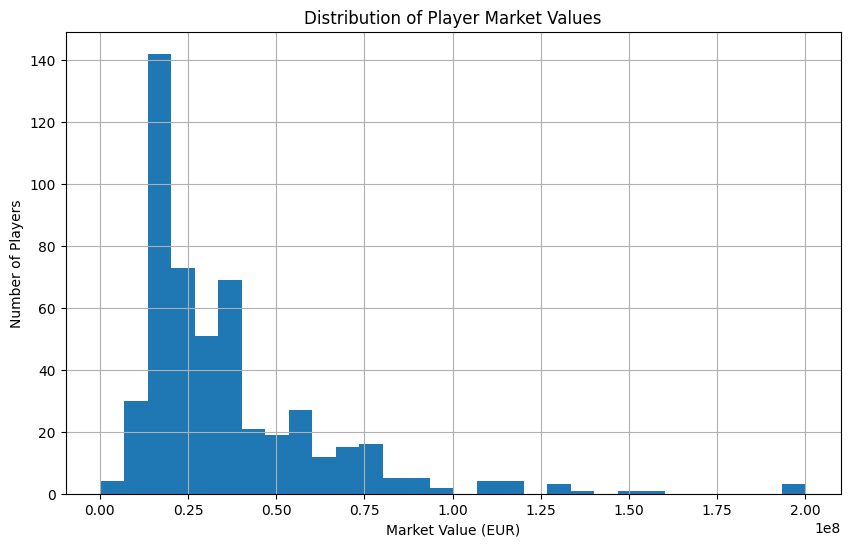

In [11]:
import matplotlib.pyplot as plt

print("Summary Statistics for Player Market Value:")
print(players["current_value_eur"].describe())

# --- Histogram (Distribution Visualization) ---
plt.figure(figsize=(10,6))

players["current_value_eur"].hist(bins=30)

plt.title("Distribution of Player Market Values")
plt.xlabel("Market Value (EUR)")
plt.ylabel("Number of Players")

plt.show()

**Descriptive Statistics and Distribution Analysis**

The dataset contains 508 players with market values measured in euros. The mean market value is approximately 36.9 million euros, while the median is 28 million euros. This means the mean is larger than the median. This means a right-skewed distribution where a small number of players have extremely high values that pull the average upward, which is shown in the graph. The standard deviation (~27.7 million euros) is relatively large, showing that player values vary significantly across the dataset. The minimum is 300,000 euros, while the maximum is 200 million euros.

The histogram visualization further supports these facts. Most players are concentrated in the lower to mid ranges, while only a few players fall into the highest ranges. This illustrates that high-value players act as outliers and contributes to the skewness of the distribution.

**Correlation**

**Hypothesis Testing**